In [1]:
# build large-scale data in scBank format from a group of AnnData objects
# %%
import gc
import json
from pathlib import Path
import argparse
import shutil
import traceback
from typing import Dict, List, Optional
import warnings
import numpy as np
import os
import anndata

import scanpy as sc
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from typing import Any, Dict, List, Mapping, Optional, Tuple, Union
from typing_extensions import Self, Literal
from scipy.sparse import issparse

import matplotlib as mpl
def set_vis_default(font = 1.6, circle_marker = 1.):
    mpl.rcParams['font.family'] = 'Arial'
    plt.rcParams.update(plt.rcParamsDefault)
#     %matplotlib inline
    try:
        plt.style.use('seaborn-whitegrid')
    except:
        plt.style.use('seaborn-v0_8-whitegrid')

    sns.set_context('paper',font_scale=font)
    plt.rcParams["legend.markerscale"] = circle_marker
    mpl.rcParams['font.family'] = 'Arial'



In [2]:
base_path = '/import/home2/xwanaf/Img2Expr/data/Reproducibility_data/PF'
file_path = Path(base_path)

file_name = 'UGE_atlas.h5ad'
atlas_adata = sc.read(file_path / file_name)
atlas_adata

AnnData object with n_obs × n_vars = 946364 × 1741
    obs: 'cell_type', 'cell_id', 'dataset_idx', 'dataset_cell_id', 'ann_finest_level', 'dataset', 'ann_level_1', 'disease', 'original_ann_nonharmonized', 'leiden_2p0', 'leiden_2p5', 'leiden_1p5', 'leiden_0p5', 'leiden_1p0', 'leiden_0p5_ct_v0', 'leiden_1p0_ct_v0', 'leiden_2p5_ct_v0', 'tmp', 'leiden_2p5_epi_v1', 'leiden_2p5_epi', 'leiden_2p5_epi_v2', 'leiden_2p5_epi_v3', 'leiden_2p5_epi_v7', 'leiden_2p5_epi_v4', 'leiden_1p_fibro_v1', 'ct_anno'
    uns: 'ann_finest_level_colors', 'dataset_colors', 'disease_colors', 'leiden_2p0_colors', 'leiden_2p5_colors', 'leiden_2p5_ct_v0_colors', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
atlas_adata.obs['ct_anno'].value_counts()

ct_anno
Alveolar macrophages             122569
Monocyte-derived Mph             109886
AT2                               95963
Ciliated                          79462
Basal                             65897
CD8 T cells                       47823
Suprabasal                        38317
CD4 T cells                       38125
NK cells                          29431
Classical monocytes               28677
EC general capillary              26455
EC venous systemic                22094
B cells                           18763
AT1                               18273
SMCs                              18011
myo-FB                            17948
DC2                               15690
Non-classical monocytes           14487
EC aerocyte capillary             11163
Mast cells                        11145
FB                                10968
EC arterial                        8914
Lymphatic EC mature                8614
Secretory MUC5B+                   7079
Secretory MUC5AC+               

# Scale the data

In [4]:
adata_scaled = atlas_adata.copy()
sc.pp.scale(adata_scaled)

In [5]:
rm_cts = [
    'Basal-Prolif', 'Squamous', 'Ionocyte', 'Neuroendocrine', 'Suprabasal',
    'Alveolar Mph proliferating',
]
adata_scaled = adata_scaled[~adata_scaled.obs['ct_anno'].isin(rm_cts)]

# Define the markers

In [7]:
markers = {
    'Epi': ['FXYD3', 'EPCAM', 'ELF3'],
    'Ciliated': ['FOXJ1'],
    'Secretory': ['SCGB3A2'],
    'Serous': ['LTF', 'MUC7'], 

    'Basal': ['TP63', 'KRT5', 'KRT17'], 
    'Aberrant Basaloid': ['CDH2', 'ITGAV', 'ITGB6'],

    'AT2': ['SFTPC', 'SFTPD', 'PGC'],
    'AT1': ['AGER', 'RTKN2', 'TMP3'],
    
    

}
markers = {key: [_ for _ in val if _ in adata_scaled.var_names] for key, val in markers.items()}


markers_genes = [_ for sublist in markers.values() for _ in sublist]
markers_genes = [
    'PECAM1'
] + ['EPCAM', 'AGER', 'SFTPC', 'FOXJ1', 'SCGB3A2', 'TP63', 'KRT5', 'KRT17'] + [
    'PTPRC', 'MS4A1', 'CD3E', 'JCHAIN', 'CPA3', 
    'HLA-DQB1', 
#     'ITGAX',
    'CD68', 'CD14', 'S100A8', 
    'COL1A1'
]
# markers_genes = markers_genes + other_markers 

In [8]:
row_order = [
    'Lymphatic EC mature',
 'EC arterial',
 'EC venous systemic',
 'EC aerocyte capillary',
 'EC general capillary',
    
    'AT1',
    'AT2',
    'Ciliated',
    'SCGB3A1+/SCGB3A2+',
    'SCGB1A1+/SCGB3A1+/SCGB3A2+',
    'SMG duct',
    
    'Basal',
    'Aberrant Basaloid',
    
    
    
    'B cells',
    'NK cells',
    'CD4 T cells',
 'CD8 T cells',
    'Plasma cells',
    'Plasmacytoid DCs',
    
    'Mast cells',
    'DC1',
    'DC2',

    
    
    'Alveolar Mph CCL3+',
 'Alveolar macrophages',
    'Interstitial Mph perivascular',
    'Monocyte-derived Mph',
     'Non-classical monocytes',
 'Classical monocytes',

    
    
    'myo-FB',
 'FB COL1A1+',
 'FB ECM',
 'FB ECM CHI3L2+',
 'FB ECM COL1A1+',
 'FB ECM SOX4+',
 'FB',
 'FB HAS1+',
    'Pericytes',
 'SMCs',
    
]

/tmp/ipykernel_3444869/1900002615.py:31: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')
/home/xwanaf/.conda/envs/scGPT/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


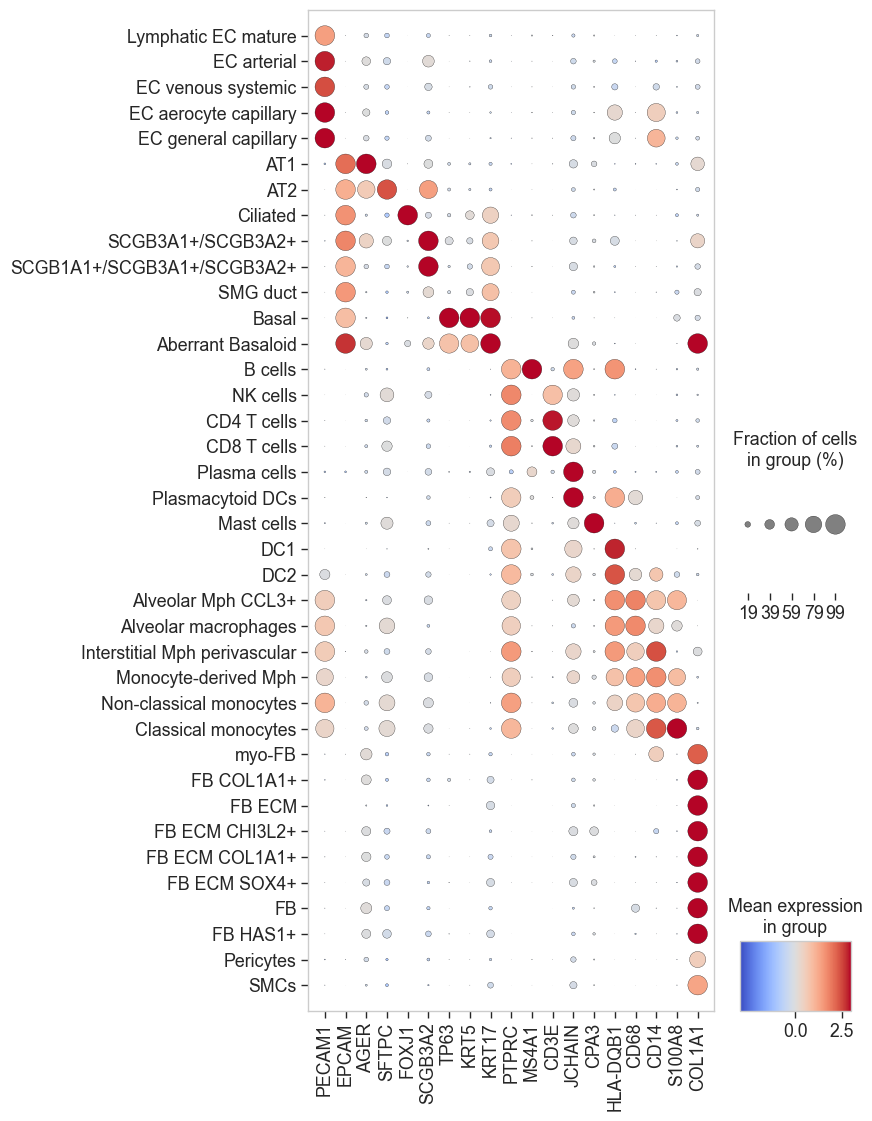

['PECAM1', 'EPCAM', 'AGER', 'SFTPC', 'FOXJ1', 'SCGB3A2', 'TP63', 'KRT5', 'KRT17', 'PTPRC', 'MS4A1', 'CD3E', 'JCHAIN', 'CPA3', 'HLA-DQB1', 'CD68', 'CD14', 'S100A8', 'COL1A1']


In [9]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.markers import MarkerStyle


vmin, vcenter, vmax = -2, .0, 4
dot_max = .5
set_vis_default(font = 1.6)
sub_dict = markers
sc.pl.dotplot(
    adata_scaled[adata_scaled.obs['ct_anno'].isin(row_order)], 
    markers_genes, 
    groupby = 'ct_anno', 
    use_raw=None, 
    var_group_rotation = 75,
    categories_order = row_order,
    
    dendrogram=False, 
    figsize = (7, 13),
    vcenter = vcenter,
    cmap = 'coolwarm',
    vmin = vmin, vmax = 3,
    swap_axes = False,
    dot_max = .99,
    return_fig=False,
    show = False
#     **{'marker': MarkerStyle("o", fillstyle="top")}
    
)
# plt.savefig(f'./save_figs/De_dotplot_overall_swap.svg', format='svg', dpi = 200, bbox_inches='tight',pad_inches=.2)
plt.show()
plt.close()
print(markers_genes)